# 01 — The final model: register-token transformer (satellite + yield history onltarget)

Self-contained reproduction of the headline result:

| cohort | RMSE | MAE | R² | nRMSE |
|---|---|---|---|---|
| **282 (headline, 10-day complete)** | **5.1** | **4.0** | **0.86** | 11.9% |
| 426 (full 2025) | 5.5 | 4.3 | 0.83 | 12.4% |

Strict 2025 holdout (model never sees any 2025 row), out-of-time validation on 2023, anomaly target over leak-free 5-yr yield history, 30-seed ensemble(seeding currently disabled). Inputs are HLS satellite window statistics + per-window coverage-% + `yield_5yr_avg` — **no soil, no climate, no coordinates, no county identity**. See `00_RESULTS_RECORD.md` for every number, provenance and the numbers-to-retire table.

Runs top-to-bottom. First run trains (~15 min end-of-season + ~70 min in-season on GPU); the per-seed cache in `cache/` makes later runs instant. Delete a cache folder to retrain.

In [1]:
# Setup — paths, device, helpers. Works when run from final_results_claude/ (or any repo subdir).
import os, glob, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

project_folder = Path.cwd()
# goes down to the project folder from Claude until it finds the Yield file
while not (project_folder / "Ertragsdaten_USA.csv").exists():
    assert project_folder.parent != project_folder, "repo root not found (looked for Ertragsdaten_USA.csv upward from cwd)"
    project_folder = project_folder.parent
ROOT = str(project_folder)
HERE  = ROOT + r"\Claude\final_results_claude"
DATA  = ROOT + r"\Claude\data_cache"
CACHE = HERE + r"\cache"
FIGS = HERE + r"\figs"
os.makedirs(CACHE, exist_ok=True)
os.makedirs(FIGS, exist_ok=True)

torch.backends.cuda.enable_flash_sdp(False)            # Blackwell math-SDPA workaround
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_math_sdp(True)
dev = "cuda" if torch.cuda.is_available() else "cpu"

def rmse(prediction, target): return float(np.sqrt(np.mean((np.asarray(prediction) - np.asarray(target)) ** 2)))
def mae(prediction, target):  return float(np.mean(np.abs(np.asarray(prediction) - np.asarray(target))))
def stats(prediction, target):
    prediction, target = np.asarray(prediction), np.asarray(target)
    return dict(RMSE=rmse(prediction, target), MAE=mae(prediction, target),
                R2=float(1 - (np.sum((target-prediction) ** 2) / np.sum((target - target.mean()) ** 2))),
                nRMSE=float(rmse(prediction, target) / target.mean() * 100))
print("ROOT =", ROOT, "| device =", dev)

ROOT = <repository> | device = cuda


## 1. Data
County-mean 20-day window statistics (Apr 7 – Aug 24) + leak-free yield history.

In [2]:
# County-mean 20d feature table — one row per county-year: 7 twenty-day windows x 104 band
# statistics + leak-free 5-yr yield history
FEAT = DATA + r"\features_20d_leakfree.parquet"
YEARS = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2025]
WIN, HIST_K = 7, 5

df = pd.read_parquet(FEAT); df["county_id"] = df.county_id.astype(str)
print("features:", df.shape)
print(df.year.value_counts().sort_index().to_string())

features: (4120, 732)
year
2016    499
2017    508
2018    422
2019    503
2020    504
2021    307
2022    438
2023    513
2025    426


In [3]:
# Per-window satellite coverage (fraction of the county's wheat pixels observed each window)
# — used only as a bias on the pooling attention
CNT = DATA + r"\counts_20d.parquet"
cnt = pd.read_parquet(CNT)
cnt["county_id"] = cnt.county_id.astype(str)
df = df.merge(cnt[["county_id", "year", "wheat_pix"] + [f"satc_w{w:02d}" for w in range(WIN)]],
              on=["county_id", "year"], how="left")
print("counts joined:", df.shape)

counts joined: (4120, 740)


In [4]:
# Evaluation cohorts (built by 00_preprocessing.ipynb):
#   HEADLINE = 2025 county-years with complete 10-day coverage (well observed), n=282
#   FULL     = every 2025 county-year in the feature table, n=426 (includes counties whose
#              10-day coverage is incomplete, which are systematically harder)
# The model always uses the 20-day features; the 10-day series only defines observedness.
cohort_file = CACHE + r"\cohort_10d_2025.txt"
assert os.path.exists(cohort_file), "run 00_preprocessing.ipynb first (it builds the cohort)"
cohort = set(open(cohort_file).read().split())
print("headline cohort:", len(cohort), "counties (expect 282)")

headline cohort: 282 counties (expect 282)


## 2. Tokens, split, scaling

In [5]:
# Lean per-window tokens: 8 bands x (mean, stdDev) + 6 spectral indices + 5 temporal deltas
# = 27 dims per window (vs 104 full stats — accuracy-neutral, 4x smaller; see record §2).
BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "NDVI", "GCVI"]
DELTA_BANDS = ["NDVI", "GCVI", "B5", "B4", "B6"]

def safe_division(numerator, denominator):
    """Divide element-wise and return NaN where the denominator is nearly zero."""
    denominator_is_valid = np.abs(denominator) > 1e-9

    division_result = np.full(
        shape=numerator.shape,
        fill_value=np.nan,
        dtype=np.float32
    )

    division_result[denominator_is_valid] = (
        numerator[denominator_is_valid]
        / denominator[denominator_is_valid]
    )

    return division_result

# creates the dataset that is actually used for the model, cutting features that are not used in the model (lean tokens)
def lean_tokens(data, nw=7):
    len_Data = len(data)
    # get window column (or NaN if missing) for lean tokenization
    def col(window_number, feature_name):
        column_name = f"w{window_number:02d}_{feature_name}"

        if column_name in data.columns:
            column_values = data[column_name].to_numpy(dtype=np.float32)
            return column_values
        else:
            missing_values = np.full(
            shape=len_Data,
            fill_value=np.nan,
            dtype=np.float32
            )
            return missing_values

    toks = []
    for w in range(nw):
        fs = []
        for b in BANDS:
            fs += [col(w, f"{b}_mean"), col(w, f"{b}_stdDev")]
        
        # calculates the VI indices that are used from specific bands (NDVI, GCVI, etc.) and adds them to the feature set
        b2, b3, b4, b5, b6, b7 = (col(w, f"{b}_mean") for b in ["B2", "B3", "B4", "B5", "B6", "B7"])
        fs += [safe_division(b5-b4, b5+b4), safe_division(b7-b4, b7+b4), safe_division(b5-b6, b5+b6), safe_division(b5-b7, b5+b7), safe_division(b5, b3)]
        den = b5 + 6*b4 - 7.5*b2 + 1
        fs.append(np.where(np.abs(den) > 1e-6, 2.5*(b5-b4)/den, np.nan).astype(np.float32))
        
        # can only calculate the delta between windows if the previous window exists, otherwise fill with zeros
        for b in DELTA_BANDS:
            if w == 0:
                fs.append(np.zeros(len_Data, np.float32))
            else:
                fs.append((col(w, f"{b}_mean") - col(w-1, f"{b}_mean")).astype(np.float32))
        toks.append(np.stack(fs, axis=1))  # (N, 27)
    return np.stack(toks, axis=1)                              # (N, nw, 27)

lean_data = lean_tokens(df, WIN)
print("lean tokens:", lean_data.shape)

lean tokens: (4120, 7, 27)


In [6]:
# Canonical split & scaling: train = 2016-2022 (+2016..), val = ALL of 2023 (out-of-time —
# essential, random val costs +0.4, record §5), test = ALL of 2025 (never seen in any form).
# Target = anomaly (yield − 5yr history); scalers fit on train only.
hist = df["yield_5yr_avg"].to_numpy(np.float32)
yield_all = df["yield"].to_numpy(np.float32)
year = df.year.to_numpy()
cid = df.county_id.to_numpy()
tr = (year != 2025) & (year != 2023)
va = year == 2023
te = year == 2025
hist = np.where(np.isnan(hist), np.nanmedian(hist[tr]), hist)
mu = np.nanmean(lean_data[tr], axis = (0, 1)) # resulting shape is (27,) for the mean of the 27 features per window
sd_ = np.nanstd(lean_data[tr], axis =  (0, 1)) + 1e-6 # has features with sd of 0, so add a small value to avoid division by zero
standardized_data = np.nan_to_num((lean_data - mu) / sd_)
TR_Yield_mean_minus_history, TR_SD_mean_minus_history = float((yield_all[tr] - hist[tr]).mean()), float((yield_all[tr] - hist[tr]).std())

# standardize the satellite data by centering data on 0 (subtract mean and divide by std) and replacing NaN values with the median of the training set
def zfit(v):
    v = np.asarray(v, np.float32)
    v = np.where(np.isnan(v), np.nanmedian(v[tr]), v)
    return ((v - v[tr].mean()) / (v[tr].std() + 1e-6)).astype(np.float32)

wheat_tot = np.maximum(df.wheat_pix.to_numpy(np.float32), 1.0)
# clips the satellite coverage values to be between 0 and 1.5, then standardizes them using zfit and stacks them into a 2D array with shape (N, WIN)
sat_covrage = np.stack([zfit(np.clip(df[f"satc_w{w:02d}"].to_numpy(np.float32) / wheat_tot, 0, 1.5))
                for w in range(WIN)], axis = 1)

yte = yield_all[te]
headline_test_set = np.array([c in cohort for c in cid[te]])
print(f"train {tr.sum()} | val(2023) {va.sum()} | test(2025) {te.sum()} (headline cohort {headline_test_set.sum()})")

train 3181 | val(2023) 513 | test(2025) 426 (headline cohort 282)


## 3. Model + 30-seed ensemble

In [7]:
# THE FINAL MODEL — register-token transformer. Inputs: satellite window tokens + coverage-%
# + yield history. The cross-attention block attends to 18 LEARNED register tokens (pure
# parameters — no soil or any other external data).

D, K = 256, 18

class YIELD_PREDICTOR(nn.Module):
    def __init__(self, input_size_window, k=K, d=D, nwin=WIN):
        super().__init__()
        self.proj = nn.Linear(input_size_window, d)
        self.pos = nn.Parameter(torch.zeros(nwin, d))
        self.enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(d, 4, 2*d, 0.1, activation="gelu", batch_first=True, norm_first=True), 1)
        self.reg = nn.Parameter(torch.randn(k, d) * 0.02)
        self.xattn = nn.MultiheadAttention(d, 4, dropout=0.1, batch_first=True)
        self.xnorm = nn.LayerNorm(d)
        self.attn = nn.Linear(d, 1)
        self.pct_scale = nn.Parameter(torch.tensor(0.5))
        self.stat = nn.Sequential(nn.Linear(1, d), nn.GELU())
        self.head = nn.Sequential(nn.Linear(2*d, d), nn.GELU(), nn.Dropout(0.1), nn.Linear(d, 1))
    def forward(self, x, h, pc):
        z = self.enc(self.proj(x) + self.pos)
        st = self.reg.unsqueeze(0).expand(x.size(0), -1, -1)
        c, _ = self.xattn(z, st, st)
        z = self.xnorm(z + c)
        a = (self.attn(z).squeeze(-1) + self.pct_scale * pc).softmax(1).unsqueeze(-1)
        return self.head(torch.cat([(z*a).sum(1), self.stat(h)], 1))

def train_register(seed, standardized_dataa=None, sat_covragee=None, tr_dataa=None, va_dataa=None, te_dataa=None):
    standardized_dataa = standardized_data if standardized_dataa is None else standardized_dataa; 
    sat_covragee = sat_covrage if sat_covragee is None else sat_covragee
    tr_dataa = tr if tr_dataa is None else tr_dataa
    va_dataa = va if va_dataa is None else va_dataa
    te_dataa = te if te_dataa is None else te_dataa
    # seeds were used in development to ensure reproducibility of the model training process. No longer used, but left in the code. 
    #torch.manual_seed(seed)
    g = np.random.default_rng()

    
    Target_tr = torch.tensor(((yield_all[tr_dataa] - hist[tr_dataa] - TR_Yield_mean_minus_history) / TR_SD_mean_minus_history)[:, None], device=dev)

    # defines my training, validation, and test datasets as tensors on the specified device (GPU)
    Dataa_tr, H_tr, sat_cov_tr = torch.tensor(standardized_dataa[tr_dataa], device=dev), torch.tensor((hist[:, None])[ tr_dataa], device=dev), torch.tensor(sat_covragee[tr_dataa], device=dev)
    Dataa_va, H_va, sat_cov_va = torch.tensor(standardized_dataa[va_dataa], device=dev), torch.tensor((hist[:, None])[ va_dataa], device=dev), torch.tensor(sat_covragee[va_dataa], device=dev)
    Dataa_te, H_te, sat_cov_te = torch.tensor(standardized_dataa[te_dataa], device=dev), torch.tensor((hist[:, None])[ te_dataa], device=dev), torch.tensor(sat_covragee[te_dataa], device=dev)
    
    # Loads model, optimizer, scheduler, and loss function 
    m = YIELD_PREDICTOR(standardized_dataa.shape[2], nwin=standardized_dataa.shape[1]).to(dev)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, 300)
    lossf = nn.SmoothL1Loss()
    
    #
    best_validation_rmse, bstate, epochs_without_improvement = 1e9, None, 0
    for ep in range(300):
        m.train()
        idx = g.permutation(len(Dataa_tr))
        for i in range(0, len(idx), 64):
            # uses batch size of 64 to train the model
            random_idx = idx[i:i+64]
            # add a bit of noise to the training data 
            training_data = Dataa_tr[random_idx] + torch.randn_like(Dataa_tr[random_idx]) * 0.03
            opt.zero_grad() # resets the gradients of the model parameters to zero before computing the gradients for the current batch
            loss = lossf(m(training_data, H_tr[random_idx], sat_cov_tr[random_idx]), Target_tr[random_idx]) #calculates the loss
            loss.backward()
            opt.step()
        sch.step()
        m.eval()
        with torch.no_grad():
            prediction_val = m(Dataa_va, H_va, sat_cov_va).squeeze(1).cpu().numpy() * TR_SD_mean_minus_history + TR_Yield_mean_minus_history + hist[va_dataa]
        validation_rmse = rmse(prediction_val, yield_all[va_dataa])    
        minimum_improvement = 1e-4
        patience = 25
        if validation_rmse < best_validation_rmse - minimum_improvement:
            best_validation_rmse = validation_rmse
            bstate = {
                parameter_name: parameter_value.detach().cpu().clone()
                for parameter_name, parameter_value in m.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            break    
    m.load_state_dict(bstate)
    m.eval()
    with torch.no_grad():
        return m(Dataa_te, H_te, sat_cov_te).squeeze(1).cpu().numpy() * TR_SD_mean_minus_history + TR_Yield_mean_minus_history + hist[te_dataa]

In [8]:
# 30-seed ensemble (the canonical protocol — ensemble size is a trade off between stability and compute budget) currently seeding is disabled
# Per-seed cache: first full run ~15 min GPU, later runs reload instantly.
NSEED = 30
BANK = CACHE + r"\headline_seeds"
os.makedirs(BANK, exist_ok=True)
t0 = time.time()
preds = []
for s in range(NSEED):
    fp = BANK + rf"\seed_{s}.npz"
    if os.path.exists(fp): test_prediction = np.load(fp)["test"]
    else:
        test_prediction = train_register(s)
        np.savez(fp, test=test_prediction)
        print(f"  seed {s} done ({time.time()-t0:.0f}s)", flush=True)
    preds.append(test_prediction)
ensemble_predictions = np.array(preds).mean(0)
statistics_headline = stats(ensemble_predictions[headline_test_set], yte[headline_test_set])
statistics_2025 = stats(ensemble_predictions, yte)
res = pd.DataFrame([{"cohort": f"{headline_test_set.sum()} (headline, 10-day complete)", **{k: round(v, 3) for k, v in statistics_headline.items()}},
                    {"cohort": f"{te.sum()} (full 2025)", **{k: round(v, 3) for k, v in statistics_2025.items()}}])
display(res)
assert abs(statistics_headline["RMSE"] - 5.1) < 0.2, "headline should reproduce ~5.1 (seed cache intact?)"

<home>\AppData\Local\Temp\ipykernel_32168\4040970364.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(d, 4, 2*d, 0.1, activation="gelu", batch_first=True, norm_first=True), 1)


  seed 0 done (10s)


<home>\AppData\Local\Temp\ipykernel_32168\4040970364.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(d, 4, 2*d, 0.1, activation="gelu", batch_first=True, norm_first=True), 1)


  seed 1 done (28s)
  seed 2 done (42s)
  seed 3 done (52s)
  seed 4 done (66s)
  seed 5 done (75s)
  seed 6 done (84s)
  seed 7 done (100s)
  seed 8 done (114s)
  seed 9 done (122s)
  seed 10 done (130s)
  seed 11 done (143s)
  seed 12 done (154s)
  seed 13 done (163s)
  seed 14 done (172s)
  seed 15 done (183s)
  seed 16 done (195s)
  seed 17 done (203s)
  seed 18 done (216s)
  seed 19 done (225s)
  seed 20 done (234s)
  seed 21 done (255s)
  seed 22 done (266s)
  seed 23 done (279s)
  seed 24 done (288s)
  seed 25 done (297s)
  seed 26 done (320s)
  seed 27 done (329s)
  seed 28 done (342s)
  seed 29 done (351s)


,cohort,RMSE,MAE,R2,nRMSE
0,"282 (headline, 10-day complete)",5.084,3.947,0.868,11.888
1,426 (full 2025),5.581,4.363,0.830,12.454


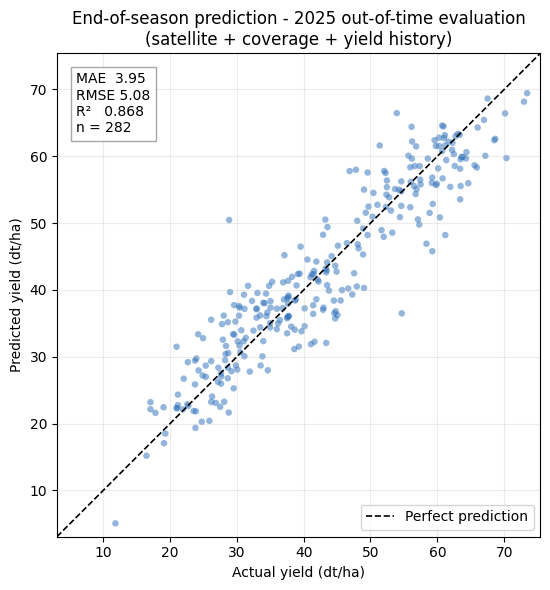

In [9]:
actual_headline_yield = yte[headline_test_set]
predicted_headline_yield = ensemble_predictions[headline_test_set]
lower_plot_limit = min( actual_headline_yield.min(), predicted_headline_yield.min()) - 2
upper_plot_limit = max( actual_headline_yield.max(), predicted_headline_yield.max()) + 2
figure, axis = plt.subplots(figsize=(6.2, 6))
axis.scatter( actual_headline_yield, predicted_headline_yield, s=22,alpha=0.5,color="#2c6fbb",edgecolor="none")
axis.plot([lower_plot_limit, upper_plot_limit],[lower_plot_limit, upper_plot_limit],"k--",linewidth=1.2,label="Perfect prediction")
axis.set_xlim(lower_plot_limit, upper_plot_limit)
axis.set_ylim(lower_plot_limit, upper_plot_limit)
axis.set_aspect("equal")
axis.set_xlabel("Actual yield (dt/ha)")
axis.set_ylabel("Predicted yield (dt/ha)")
axis.set_title( "End-of-season prediction - 2025 out-of-time evaluation\n""(satellite + coverage + yield history)")
statistics_text = (f"MAE  {statistics_headline['MAE']:.2f}\n"
    f"RMSE {statistics_headline['RMSE']:.2f}\n"
    f"R²   {statistics_headline['R2']:.3f}\n"
    f"n = {len(actual_headline_yield)}")
axis.text(0.04, 0.96,statistics_text,transform=axis.transAxes,verticalalignment="top",horizontalalignment="left",
          bbox={"facecolor": "white","edgecolor": "#999","alpha": 0.85})
axis.grid(alpha=0.25)
axis.legend(loc="lower right")
figure.tight_layout()
figure_path = os.path.join(FIGS, "fig1_parity_final.png")
figure.savefig(figure_path, dpi=150)
plt.show()

## 4. In-season forecast skill
~92% of final skill by late June, ~98% by Jul 15 — full forecasting skill about six weeks before harvest. (Known nuance, record §4: in the very early season (Matarget) full 104-dim tokens beat the lean tokens by up to ~0.5 RMSE; all models tie from late June.)

In [10]:
# In-season skill curve — the SAME model prefix-retrained per horizon (a horizon-h forecast
# uses only windows 0..h-1; features and scalers re-derived on the prefix). 30 seeds/horizon,
# per-seed cache (first full run ~70 min GPU; cached runs are instant).
class PrefixYIELD_PREDICTOR(YIELD_PREDICTOR):
    pass                                                   # same architechture

IBANK = CACHE + r"\inseason_D"
os.makedirs(IBANK, exist_ok=True)
WEND = ["Apr 26", "May 16", "Jun 5", "Jun 25", "Jul 15", "Aug 4", "Aug 24"]
t0 = time.time()
# headline_RMSE / headline_MAE / alltest_RMSE collect the RMSE and MAE for each window
headline_RMSE, headline_MAE, alltest_RMSE = [], [], []

# calcualtes baseline RMSE and MAE to beat. Just predict avg. of last 5 years 
H_te = hist[te]
base_r, base_m = rmse(H_te[headline_test_set], yte[headline_test_set]), mae(H_te[headline_test_set], yte[headline_test_set])

# starts looking at windows only after the first window exists, and goes through all the windows to calculate the RMSE and MAE for each window
# 
for window_h in range(1, WIN + 1):
    preds_h = []
    for s in range(NSEED):
        fp = IBANK + rf"\D_h{window_h}_seed{s}.npy"
        if os.path.exists(fp): test_prediction_up_to_h = np.load(fp)
        else:
            # looks only at certain windows using :window_h to cut windows from the data
            data_up_to_h = lean_data[:, :window_h, :].copy()
            mean_up_to_h = np.nanmean(data_up_to_h[tr], (0, 1))
            sd_up_to_h = np.nanstd(data_up_to_h[tr], (0, 1)) + 1e-6
            test_prediction_up_to_h = train_register(s, standardized_dataa=np.nan_to_num((data_up_to_h - mean_up_to_h) / sd_up_to_h), sat_covragee=sat_covrage[:, :window_h])
            np.save(fp, test_prediction_up_to_h)
        preds_h.append(test_prediction_up_to_h)

    ensemble_predictions_h = np.array(preds_h).mean(0)
    headline_RMSE.append(rmse(ensemble_predictions_h[headline_test_set], yte[headline_test_set]))
    headline_MAE.append(mae(ensemble_predictions_h[headline_test_set], yte[headline_test_set]))
    alltest_RMSE.append(rmse(ensemble_predictions_h, yte))
    print(f"  h{window_h} ({WEND[window_h-1]:6s}): headline RMSE {headline_RMSE[-1]:.3f} MAE {headline_MAE[-1]:.3f} | full {alltest_RMSE[-1]:.3f} ({time.time()-t0:.0f}s)", flush=True)

curve = pd.DataFrame({"date": ["pre-season"] + WEND, "rmse": [base_r] + headline_RMSE,
                      "mae": [base_m] + headline_MAE, "rmse_full": [np.nan] + alltest_RMSE})

curve.to_csv(CACHE + r"\inseason_curve_final.csv", index=False)
display(curve.round(3))

<home>\AppData\Local\Temp\ipykernel_32168\4040970364.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(d, 4, 2*d, 0.1, activation="gelu", batch_first=True, norm_first=True), 1)


  h1 (Apr 26): headline RMSE 6.140 MAE 4.855 | full 6.429 (301s)
  h2 (May 16): headline RMSE 5.905 MAE 4.623 | full 6.285 (643s)
  h3 (Jun 5 ): headline RMSE 5.658 MAE 4.500 | full 6.042 (1021s)
  h4 (Jun 25): headline RMSE 5.248 MAE 4.128 | full 5.682 (1369s)
  h5 (Jul 15): headline RMSE 5.152 MAE 4.013 | full 5.644 (1698s)
  h6 (Aug 4 ): headline RMSE 5.063 MAE 3.916 | full 5.540 (2074s)
  h7 (Aug 24): headline RMSE 5.067 MAE 3.922 | full 5.569 (2426s)


,date,rmse,mae,rmse_full
0,pre-season,7.696,6.185,NaN
1,Apr 26,6.140,4.855,6.429
2,May 16,5.905,4.623,6.285
3,Jun 5,5.658,4.500,6.042
4,Jun 25,5.248,4.128,5.682
5,Jul 15,5.152,4.013,5.644
6,Aug 4,5.063,3.916,5.540
7,Aug 24,5.067,3.922,5.569


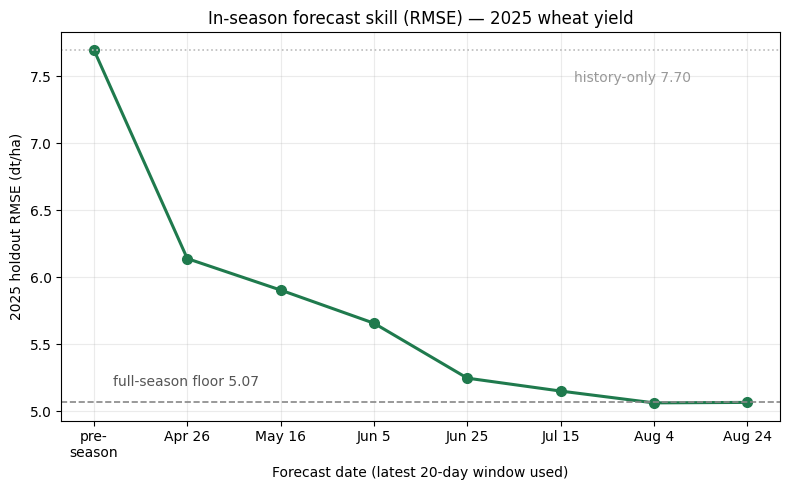

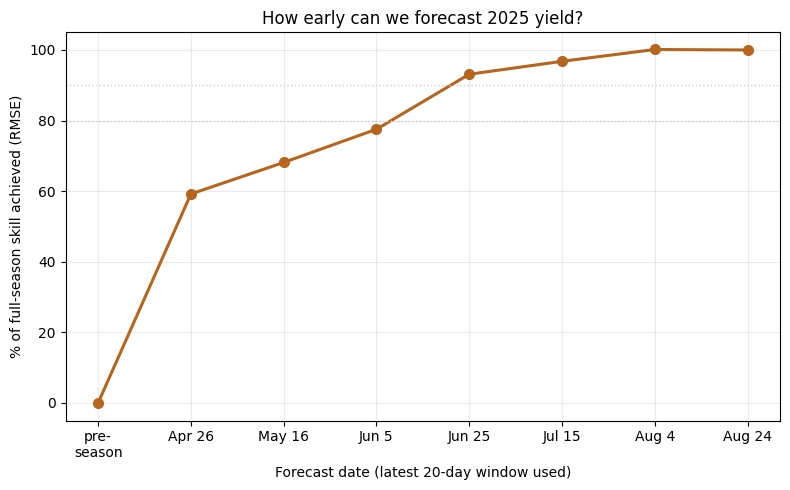

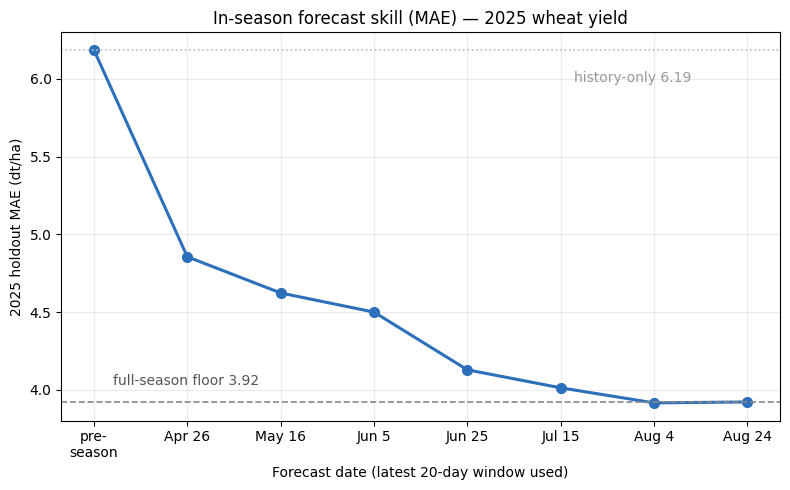

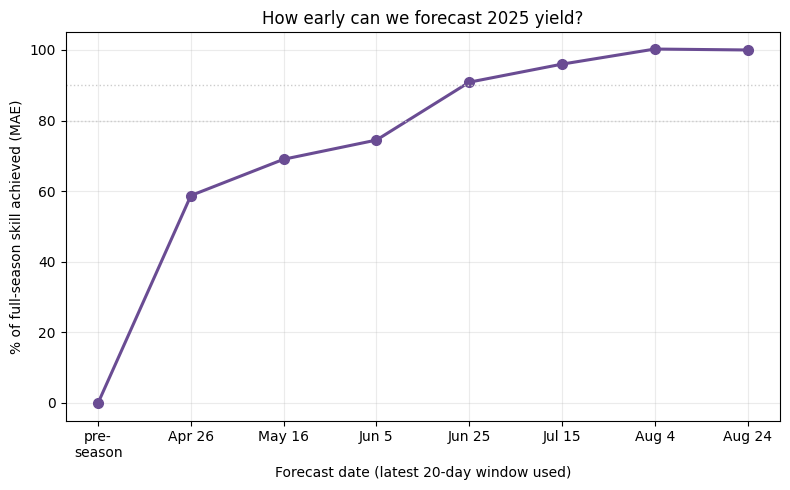

In [11]:
# Figures 2 & 3 — skill curve and %-of-skill-by-date (RMSE + MAE variants)
x = np.arange(len(curve)); labels = ["pre-\nseason"] + WEND

def render(vals, unit, c_skill, c_early, suf):
    base, full = vals[0], vals[-1]
    plt.figure(figsize=(8, 5))
    plt.plot(x, vals, "-o", color=c_skill, lw=2.2, ms=7)
    plt.axhline(full, ls="--", color="#888", lw=1.2)
    plt.text(0.2, full + 0.04 * (base - full) + 0.02, f"full-season floor {full:.2f}", color="#555", fontsize=10)
    plt.axhline(base, ls=":", color="#bbb", lw=1.2)
    plt.text(len(vals) - 1.6, base - 0.06 * (base - full), f"history-only {base:.2f}",
             color="#999", fontsize=10, ha="right", va="top")
    plt.xticks(x, labels); plt.xlabel("Forecast date (latest 20-day window used)")
    plt.ylabel(f"2025 holdout {unit} (dt/ha)")
    plt.title(f"In-season forecast skill ({unit}) — 2025 wheat yield")
    plt.grid(alpha=0.25); plt.tight_layout()
    plt.savefig(FIGS + rf"\fig2_inseason_final_{suf}.png", dpi=150); plt.show()
    frac = [100 * (base - c) / (base - full) for c in vals]
    plt.figure(figsize=(8, 5))
    plt.plot(x, frac, "-o", color=c_early, lw=2.2, ms=7)
    for thr in (80, 90): plt.axhline(thr, ls=":", color="#ccc", lw=1)
    plt.xticks(x, labels); plt.ylim(-5, 105)
    plt.xlabel("Forecast date (latest 20-day window used)")
    plt.ylabel(f"% of full-season skill achieved ({unit})")
    plt.title("How early can we forecast 2025 yield?")
    plt.grid(alpha=0.25); plt.tight_layout()
    plt.savefig(FIGS + rf"\fig3_how_early_final_{suf}.png", dpi=150); plt.show()

render(curve.rmse.tolist(), "RMSE", "#1f7a4d", "#b5651d", "rmse")
render(curve.mae.tolist(), "MAE", "#2c6fbb", "#6a4c93", "mae")

## Summary
- **End of season: Around RMSE 5.1 / MAE 4 / R² 0.86** on the 282-county headline cohort; 5.5 / 4.3 / 0.83 on the full 426.
- Within ~1.5–3.3% of the published soil+climate frontier (Cao 5.1, GAT 5.01) using satellite + history only.
- Full in-season skill ~6 weeks pre-harvest; last six weeks add ≤0.06 RMSE.
- Why the cross-attention block needs no soil: notebook `02`. Why this is the data's ceiling: notebooks `02`–`06` + record §8.